# Required Imports

In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import amf.helper.load as AmfLoad
import amf.helper.config as AmfConfig
import amf.helper.model as AmfModel
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np

# Functions and Classes

In [ ]:
def get_predictions(x, model, device, num_classes, batch_size=32):
    model.eval()
    y = len(x)*[np.zeros(num_classes)]
    inference_dataset = AmfLoad.CustomNormalisedDataset(x, y)
    test_loader = DataLoader(inference_dataset, batch_size=batch_size, shuffle=False)

    all_y_probs = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            probabilities = torch.softmax(outputs, dim=1)
            all_y_probs.append(probabilities.cpu().numpy())

    all_y_probs = np.vstack(all_y_probs)

    return all_y_probs

class Prediction:
    def __init__(self, pred_prob, true_label,img,row,col,fn):
        self.pred_label = np.argmax(pred_prob)
        self.conf = np.max(pred_prob)
        self.true_label = true_label
        self.img = img
        self.row = row
        self.col = col
        self.fn = fn
        self.prob_vector = pred_prob
        self.std = np.std(pred_prob)


# Getting Predictions

In [3]:
model = AmfModel.load()
print(model.__class__.__name__)
device = AmfConfig.get("device")
input_files = AmfConfig.find_files_in_directory("../../Training Datasets/Azure_252_csv_training")
parts = AmfLoad.categorise_path(input_files)
test_images = parts["test"]
# test_images = test_images[0:1]
dataset_loader_test = AmfLoad.TileFilesandData(test_images)
x_test, y_test, fn, rows, cols = dataset_loader_test.get_all_data()

# import random
# random_sampling = random.sample(range(0,len(x_test)),50)
# x_test = [x_test[i] for i in random_sampling]
# y_test = [y_test[i] for i in random_sampling]
# fn = [fn[i] for i in random_sampling]
# rows = [rows[i] for i in random_sampling]
# cols = [cols[i] for i in random_sampling]

[15:57:02] Model: C:\Users\d80120\Desktop\Kew\root-fungal-colonisation\amf\amf_code\trained_networks\model_misclassified_tiles.pth.


c:\Users\d80120\Desktop\Kew\root-fungal-colonisation\amf\amf_code\amfinder_model.py:402: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=

[15:57:06] Model load successful.
[15:57:06] Model type: CNN1.
[15:57:06] Classes: AM+ (amcolonised), M− (non-colonised), Background (background), Unreadable (unreadable), DSE (dse), Hybrid (hybrid)..
CNN1
[15:57:06] Tile extraction.
[15:57:06] 10 images in filtered dataset.
[15:57:16] Tile extraction.
[15:57:16] 10 images in BALD dataset.


In [4]:
model = model.to(device)
pred_probs =  get_predictions(x_test, model, device, y_test[0].shape[0])

In [ ]:
# import pickle
# with open('pred_probs_latest.pkl', 'wb') as f:
#     pickle.dump(pred_probs, f)


In [6]:
# import pickle

# with open("pred_probs_latest.pkl", "rb") as f:
#     pred_probs = pickle.load(f)


In [7]:
true_labels = [np.argmax(i) for i in y_test]
predictions_list = [Prediction(pred_probs[i], true_labels[i],x_test[i],rows[i],cols[i], fn[i]) for i in range(len(pred_probs))]

In [8]:
# import pickle
# with open('predictions_list_latest.pkl', 'wb') as f:
#     pickle.dump(predictions_list, f)

# Collecting Predictions In a Structured Manner

In [9]:
from collections import defaultdict
classwise_predictions = defaultdict(lambda: {"correct": [], "incorrect": []})

# Populate dictionary
for pred in predictions_list:
    if pred.pred_label == pred.true_label:
        classwise_predictions[pred.true_label]["correct"].append(pred)
    else:
        classwise_predictions[pred.true_label]["incorrect"].append(pred)

# Sort both lists in each class by confidence (descending)
for class_label in classwise_predictions:
    classwise_predictions[class_label]["correct"].sort(key=lambda x: x.conf, reverse=True)
    classwise_predictions[class_label]["incorrect"].sort(key=lambda x: x.conf, reverse=True)

# Visualisations

Predicted Label: M−
Confidence: 0.99666375
True Label: DSE
Row: 40
Col: 24
Vector: [0.00, 1.00, 0.00, 0.00, 0.00, 0.00]
Std 0.37118763


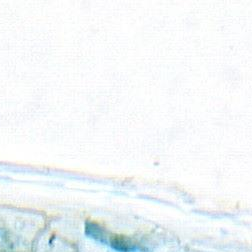

Predicted Label: M−
Confidence: 0.98557276
True Label: DSE
Row: 33
Col: 36
Vector: [0.01, 0.99, 0.00, 0.00, 0.00, 0.00]
Std 0.36626032


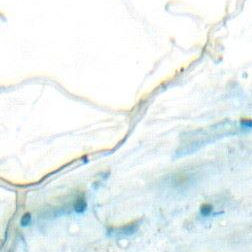

Predicted Label: M−
Confidence: 0.9830372
True Label: DSE
Row: 40
Col: 12
Vector: [0.02, 0.98, 0.00, 0.00, 0.00, 0.00]
Std 0.36514416


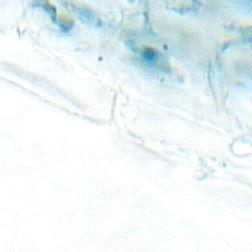

Predicted Label: M−
Confidence: 0.9704129
True Label: DSE
Row: 33
Col: 9
Vector: [0.03, 0.97, 0.00, 0.00, 0.00, 0.00]
Std 0.35960117


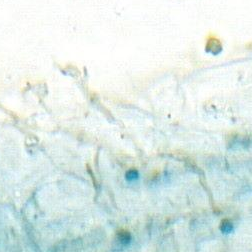

Predicted Label: AM+
Confidence: 0.96135414
True Label: DSE
Row: 15
Col: 58
Vector: [0.96, 0.04, 0.00, 0.00, 0.00, 0.00]
Std 0.35566232


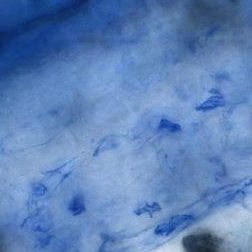

Predicted Label: M−
Confidence: 0.9595387
True Label: DSE
Row: 12
Col: 56
Vector: [0.03, 0.96, 0.00, 0.01, 0.00, 0.00]
Std 0.35478106


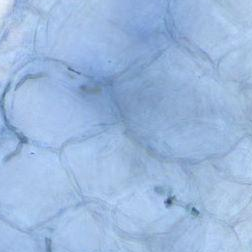

Predicted Label: AM+
Confidence: 0.9581469
True Label: DSE
Row: 15
Col: 56
Vector: [0.96, 0.04, 0.00, 0.00, 0.00, 0.00]
Std 0.354286


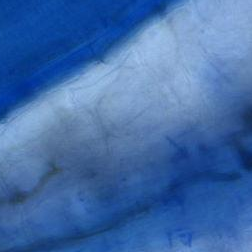

Predicted Label: M−
Confidence: 0.9563324
True Label: DSE
Row: 36
Col: 48
Vector: [0.04, 0.96, 0.00, 0.00, 0.00, 0.00]
Std 0.35346353


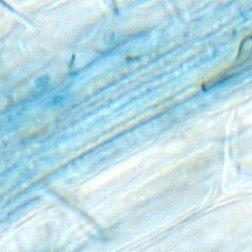

Predicted Label: Hybrid
Confidence: 0.955119
True Label: DSE
Row: 33
Col: 20
Vector: [0.03, 0.00, 0.00, 0.00, 0.01, 0.96]
Std 0.35273075


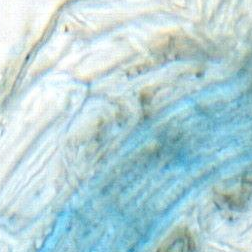

Predicted Label: M−
Confidence: 0.9547648
True Label: DSE
Row: 36
Col: 49
Vector: [0.04, 0.95, 0.00, 0.00, 0.00, 0.00]
Std 0.3528273


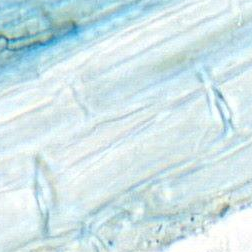

Predicted Label: AM+
Confidence: 0.9357754
True Label: DSE
Row: 22
Col: 47
Vector: [0.94, 0.06, 0.00, 0.00, 0.00, 0.00]
Std 0.34475246


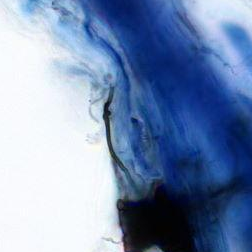

Predicted Label: AM+
Confidence: 0.9267172
True Label: DSE
Row: 25
Col: 52
Vector: [0.93, 0.04, 0.00, 0.02, 0.00, 0.01]
Std 0.34016365


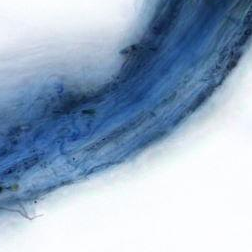

Predicted Label: M−
Confidence: 0.92668945
True Label: DSE
Row: 34
Col: 56
Vector: [0.07, 0.93, 0.00, 0.00, 0.00, 0.00]
Std 0.34094402


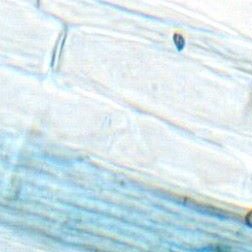

Predicted Label: AM+
Confidence: 0.91688704
True Label: DSE
Row: 14
Col: 59
Vector: [0.92, 0.08, 0.00, 0.00, 0.00, 0.00]
Std 0.3368776


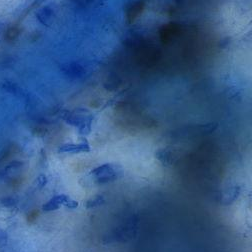

Predicted Label: M−
Confidence: 0.91484666
True Label: DSE
Row: 14
Col: 62
Vector: [0.07, 0.91, 0.00, 0.01, 0.00, 0.00]
Std 0.335649


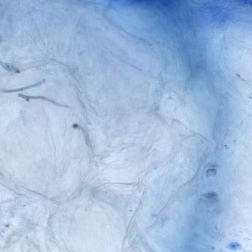

Predicted Label: AM+
Confidence: 0.91141015
True Label: DSE
Row: 13
Col: 58
Vector: [0.91, 0.09, 0.00, 0.00, 0.00, 0.00]
Std 0.33462664


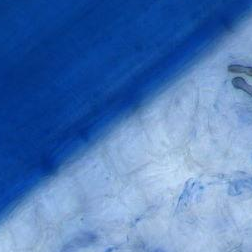

Predicted Label: AM+
Confidence: 0.8955255
True Label: DSE
Row: 21
Col: 46
Vector: [0.90, 0.07, 0.00, 0.00, 0.03, 0.00]
Std 0.326902


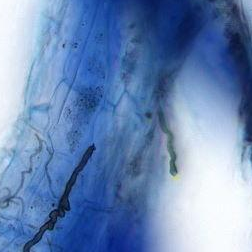

Predicted Label: AM+
Confidence: 0.89271957
True Label: DSE
Row: 22
Col: 46
Vector: [0.89, 0.11, 0.00, 0.00, 0.00, 0.00]
Std 0.32694334


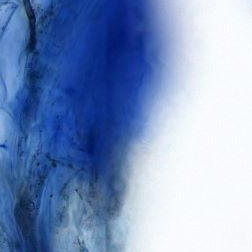

Predicted Label: M−
Confidence: 0.8803353
True Label: DSE
Row: 31
Col: 20
Vector: [0.02, 0.88, 0.00, 0.03, 0.07, 0.00]
Std 0.31994838


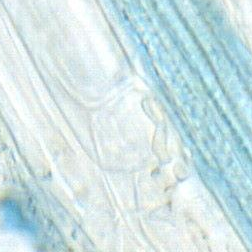

Predicted Label: M−
Confidence: 0.8744626
True Label: DSE
Row: 34
Col: 57
Vector: [0.07, 0.87, 0.00, 0.00, 0.05, 0.00]
Std 0.31764862


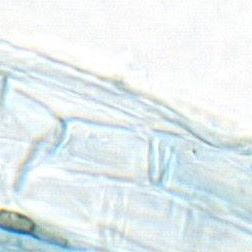

Predicted Label: M−
Confidence: 0.87413275
True Label: DSE
Row: 34
Col: 34
Vector: [0.03, 0.87, 0.00, 0.00, 0.09, 0.00]
Std 0.3178484


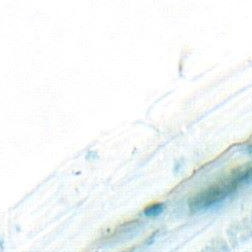

Predicted Label: M−
Confidence: 0.86422753
True Label: DSE
Row: 44
Col: 104
Vector: [0.01, 0.86, 0.06, 0.07, 0.00, 0.00]
Std 0.3132536


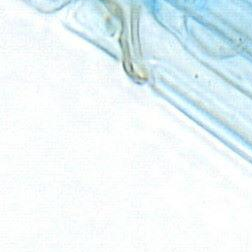

Predicted Label: M−
Confidence: 0.82889163
True Label: DSE
Row: 41
Col: 42
Vector: [0.03, 0.83, 0.00, 0.05, 0.08, 0.00]
Std 0.29754895


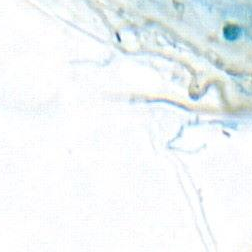

Predicted Label: M−
Confidence: 0.81938195
True Label: DSE
Row: 34
Col: 41
Vector: [0.00, 0.82, 0.01, 0.17, 0.00, 0.00]
Std 0.29821447


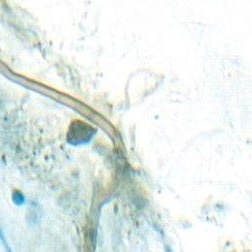

Predicted Label: Hybrid
Confidence: 0.81721044
True Label: DSE
Row: 35
Col: 26
Vector: [0.00, 0.00, 0.00, 0.00, 0.18, 0.82]
Std 0.2981164


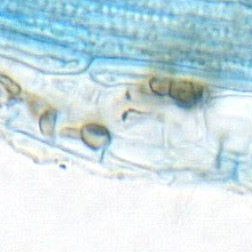

Predicted Label: M−
Confidence: 0.8118274
True Label: DSE
Row: 13
Col: 44
Vector: [0.18, 0.81, 0.00, 0.00, 0.00, 0.00]
Std 0.29620466


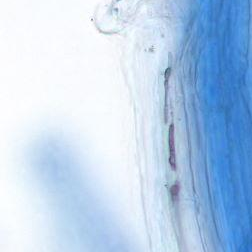

Predicted Label: AM+
Confidence: 0.8060909
True Label: DSE
Row: 17
Col: 46
Vector: [0.81, 0.19, 0.00, 0.00, 0.00, 0.00]
Std 0.2945829


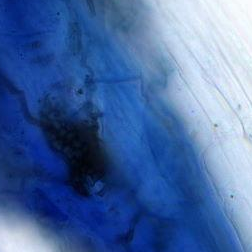

Predicted Label: AM+
Confidence: 0.80419564
True Label: DSE
Row: 11
Col: 58
Vector: [0.80, 0.03, 0.00, 0.03, 0.06, 0.08]
Std 0.28610876


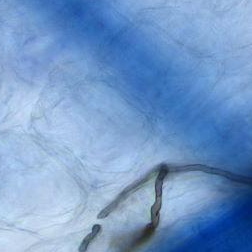

Predicted Label: AM+
Confidence: 0.78943664
True Label: DSE
Row: 25
Col: 51
Vector: [0.79, 0.20, 0.00, 0.01, 0.00, 0.00]
Std 0.28756195


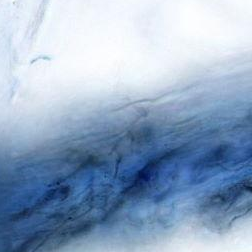

Predicted Label: AM+
Confidence: 0.7849375
True Label: DSE
Row: 14
Col: 65
Vector: [0.78, 0.22, 0.00, 0.00, 0.00, 0.00]
Std 0.2874342


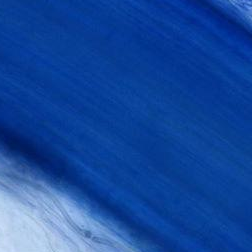

Predicted Label: AM+
Confidence: 0.78284496
True Label: DSE
Row: 13
Col: 60
Vector: [0.78, 0.20, 0.00, 0.01, 0.00, 0.01]
Std 0.28420773


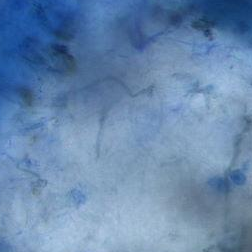

Predicted Label: M−
Confidence: 0.74686086
True Label: DSE
Row: 35
Col: 57
Vector: [0.21, 0.75, 0.00, 0.00, 0.02, 0.02]
Std 0.26987854


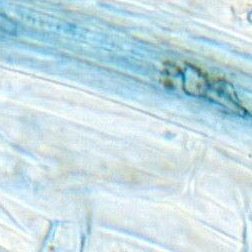

Predicted Label: Hybrid
Confidence: 0.74230886
True Label: DSE
Row: 41
Col: 43
Vector: [0.03, 0.01, 0.00, 0.00, 0.21, 0.74]
Std 0.26796913


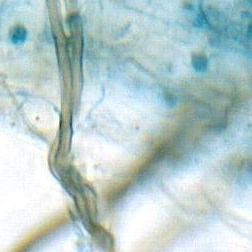

Predicted Label: Unreadable
Confidence: 0.7404281
True Label: DSE
Row: 0
Col: 23
Vector: [0.04, 0.10, 0.00, 0.74, 0.11, 0.00]
Std 0.25989586


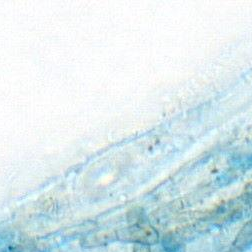

Predicted Label: AM+
Confidence: 0.7343469
True Label: DSE
Row: 14
Col: 58
Vector: [0.73, 0.26, 0.00, 0.00, 0.00, 0.00]
Std 0.27130902


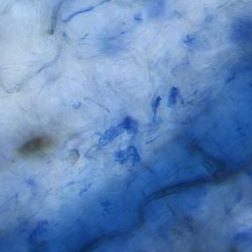

Predicted Label: M−
Confidence: 0.72737294
True Label: DSE
Row: 17
Col: 45
Vector: [0.12, 0.73, 0.01, 0.10, 0.04, 0.00]
Std 0.25436914


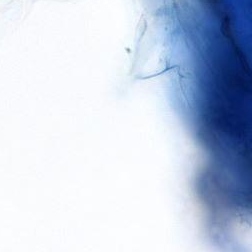

Predicted Label: M−
Confidence: 0.71898437
True Label: DSE
Row: 37
Col: 31
Vector: [0.22, 0.72, 0.00, 0.02, 0.02, 0.02]
Std 0.25873232


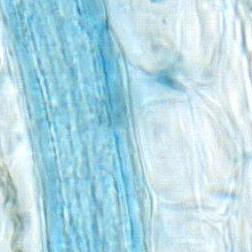

Predicted Label: AM+
Confidence: 0.70497864
True Label: DSE
Row: 24
Col: 47
Vector: [0.70, 0.29, 0.00, 0.00, 0.00, 0.00]
Std 0.2636391


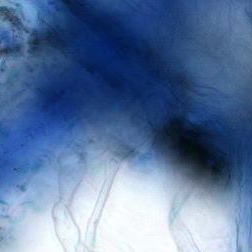

Predicted Label: AM+
Confidence: 0.6994849
True Label: DSE
Row: 13
Col: 61
Vector: [0.70, 0.30, 0.00, 0.00, 0.00, 0.00]
Std 0.26146314


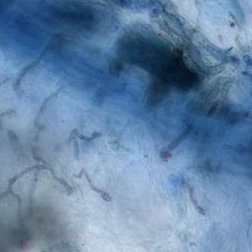

Predicted Label: Unreadable
Confidence: 0.6946553
True Label: DSE
Row: 54
Col: 55
Vector: [0.05, 0.22, 0.00, 0.69, 0.03, 0.00]
Std 0.24797249


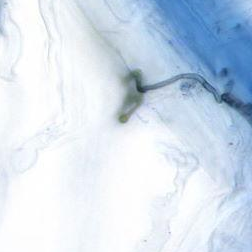

Predicted Label: M−
Confidence: 0.69142514
True Label: DSE
Row: 3
Col: 22
Vector: [0.08, 0.69, 0.04, 0.11, 0.07, 0.01]
Std 0.23656382


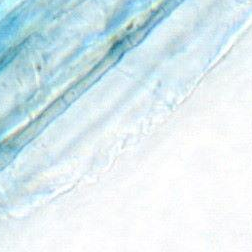

Predicted Label: AM+
Confidence: 0.6849669
True Label: DSE
Row: 13
Col: 59
Vector: [0.68, 0.19, 0.00, 0.01, 0.00, 0.11]
Std 0.24167131


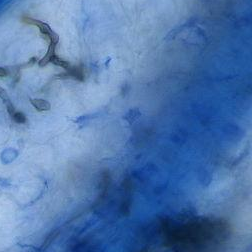

Predicted Label: M−
Confidence: 0.6764311
True Label: DSE
Row: 39
Col: 12
Vector: [0.16, 0.68, 0.00, 0.04, 0.09, 0.03]
Std 0.23306397


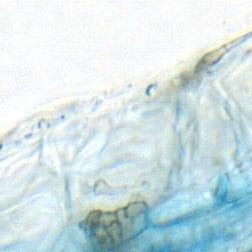

Predicted Label: M−
Confidence: 0.65874714
True Label: DSE
Row: 15
Col: 65
Vector: [0.32, 0.66, 0.00, 0.01, 0.01, 0.00]
Std 0.24863744


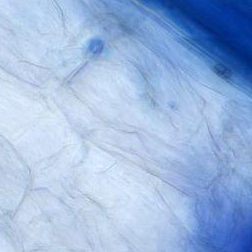

Predicted Label: Unreadable
Confidence: 0.6464014
True Label: DSE
Row: 5
Col: 20
Vector: [0.08, 0.08, 0.00, 0.65, 0.16, 0.03]
Std 0.22004567


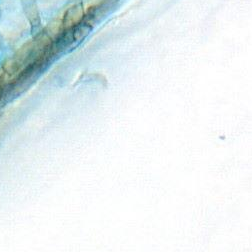

Predicted Label: AM+
Confidence: 0.6372548
True Label: DSE
Row: 34
Col: 26
Vector: [0.64, 0.36, 0.00, 0.00, 0.00, 0.00]
Std 0.24834017


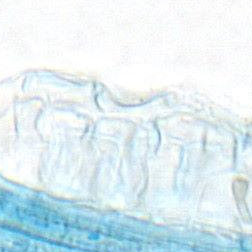

Predicted Label: AM+
Confidence: 0.6191315
True Label: DSE
Row: 15
Col: 55
Vector: [0.62, 0.38, 0.00, 0.00, 0.00, 0.00]
Std 0.24552864


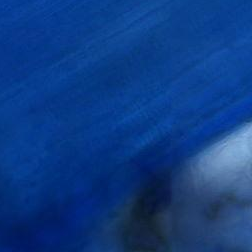

Predicted Label: M−
Confidence: 0.615529
True Label: DSE
Row: 10
Col: 62
Vector: [0.37, 0.62, 0.00, 0.01, 0.00, 0.00]
Std 0.24076916


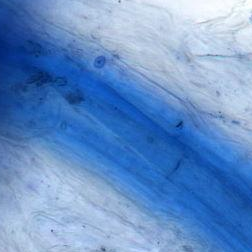

Predicted Label: AM+
Confidence: 0.6084766
True Label: DSE
Row: 34
Col: 20
Vector: [0.61, 0.17, 0.00, 0.01, 0.05, 0.16]
Std 0.20891576


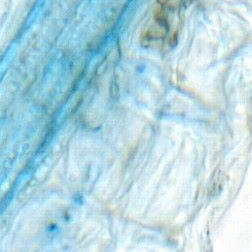

Predicted Label: AM+
Confidence: 0.60353816
True Label: DSE
Row: 17
Col: 76
Vector: [0.60, 0.39, 0.00, 0.00, 0.00, 0.00]
Std 0.24232882


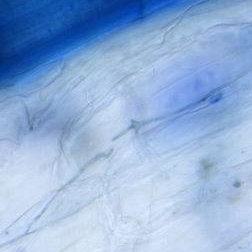

Predicted Label: M−
Confidence: 0.59418267
True Label: DSE
Row: 45
Col: 81
Vector: [0.22, 0.59, 0.01, 0.08, 0.06, 0.04]
Std 0.20234165


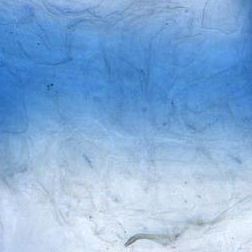

Predicted Label: M−
Confidence: 0.58726674
True Label: DSE
Row: 9
Col: 62
Vector: [0.41, 0.59, 0.00, 0.00, 0.00, 0.00]
Std 0.24082696


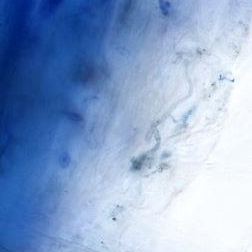

Predicted Label: M−
Confidence: 0.58163905
True Label: DSE
Row: 16
Col: 45
Vector: [0.40, 0.58, 0.00, 0.02, 0.00, 0.00]
Std 0.2350013


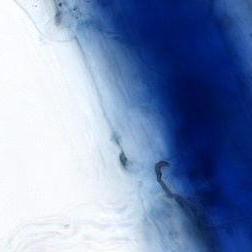

Predicted Label: M−
Confidence: 0.5765064
True Label: DSE
Row: 39
Col: 11
Vector: [0.14, 0.58, 0.05, 0.11, 0.09, 0.04]
Std 0.18628675


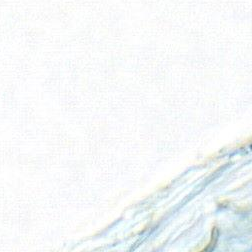

Predicted Label: M−
Confidence: 0.56752986
True Label: DSE
Row: 24
Col: 61
Vector: [0.43, 0.57, 0.00, 0.00, 0.00, 0.00]
Std 0.23889771


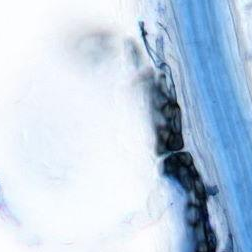

Predicted Label: M−
Confidence: 0.5610804
True Label: DSE
Row: 54
Col: 56
Vector: [0.09, 0.56, 0.00, 0.32, 0.03, 0.00]
Std 0.20682111


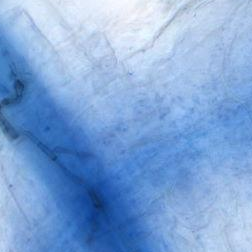

Predicted Label: M−
Confidence: 0.54778886
True Label: DSE
Row: 11
Col: 59
Vector: [0.42, 0.55, 0.00, 0.02, 0.00, 0.01]
Std 0.22831725


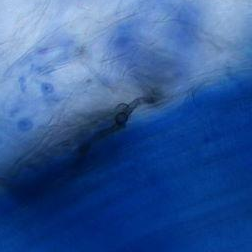

Predicted Label: AM+
Confidence: 0.53007054
True Label: DSE
Row: 12
Col: 58
Vector: [0.53, 0.47, 0.00, 0.00, 0.00, 0.00]
Std 0.2363387


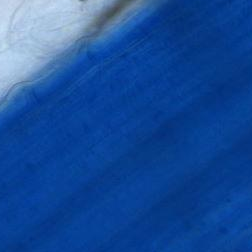

Predicted Label: M−
Confidence: 0.52099913
True Label: DSE
Row: 42
Col: 10
Vector: [0.16, 0.52, 0.00, 0.28, 0.04, 0.00]
Std 0.18654688


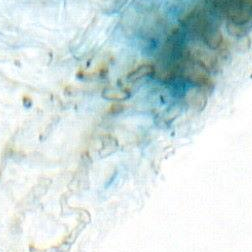

Predicted Label: M−
Confidence: 0.5056958
True Label: DSE
Row: 11
Col: 14
Vector: [0.38, 0.51, 0.00, 0.04, 0.06, 0.01]
Std 0.19868346


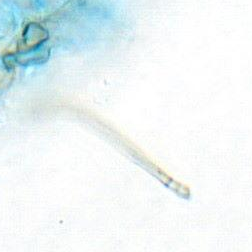

Predicted Label: Unreadable
Confidence: 0.44551542
True Label: DSE
Row: 25
Col: 61
Vector: [0.07, 0.34, 0.01, 0.45, 0.13, 0.01]
Std 0.16875365


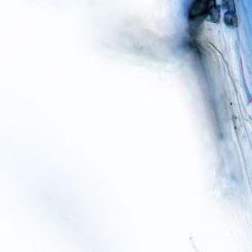

Predicted Label: M−
Confidence: 0.39997512
True Label: DSE
Row: 34
Col: 40
Vector: [0.27, 0.40, 0.00, 0.10, 0.20, 0.03]
Std 0.14000334


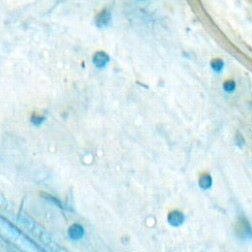

Predicted Label: AM+
Confidence: 0.39818075
True Label: DSE
Row: 34
Col: 35
Vector: [0.40, 0.20, 0.00, 0.00, 0.15, 0.25]
Std 0.13953026


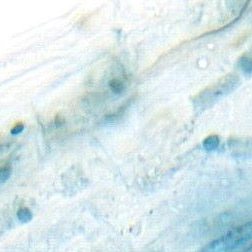

Predicted Label: M−
Confidence: 0.3856312
True Label: DSE
Row: 23
Col: 52
Vector: [0.23, 0.39, 0.00, 0.34, 0.02, 0.02]
Std 0.15755166


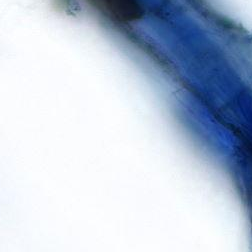

Predicted Label: AM+
Confidence: 0.37509915
True Label: DSE
Row: 23
Col: 53
Vector: [0.38, 0.25, 0.02, 0.17, 0.08, 0.10]
Std 0.11920075


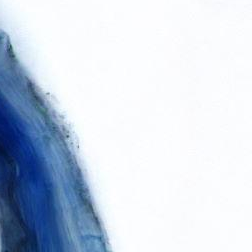

In [17]:
class_labels = ["AM+", "M−", "Background", "Unreadable", "DSE", "Hybrid"]

def visualise(prediction: Prediction):
    x = prediction.img
    print("Predicted Label:", class_labels[prediction.pred_label])
    print("Confidence:", prediction.conf)
    print("True Label:", class_labels[prediction.true_label])
    print("Row:", prediction.row)
    print("Col:", prediction.col)
    print("Vector:", "[" + ", ".join(f"{prob:.2f}" for prob in prediction.prob_vector) + "]")
    print("Std", prediction.std)
    # print(prediction.img)
    image = np.transpose(x, (1, 2, 0))
    pil_image = Image.fromarray(image)
    display(pil_image)


for i in range(0,65):
    visualise(classwise_predictions[4]["incorrect"][i])


# Confused Predictions

Predicted Label: Unreadable
Confidence: 0.25047842
True Label: M−
Row: 25
Col: 85
Vector: [0.17, 0.23, 0.11, 0.25, 0.15, 0.09]
Std 0.058513355


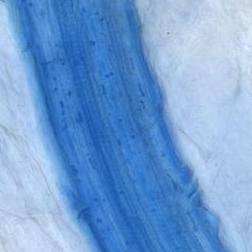

Predicted Label: DSE
Confidence: 0.24404047
True Label: M−
Row: 80
Col: 17
Vector: [0.20, 0.18, 0.05, 0.19, 0.24, 0.14]
Std 0.061267797


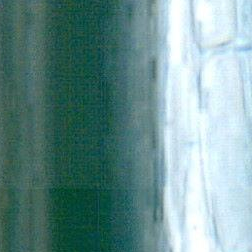

Predicted Label: M−
Confidence: 0.2599036
True Label: M−
Row: 20
Col: 71
Vector: [0.18, 0.26, 0.07, 0.22, 0.16, 0.11]
Std 0.061733846


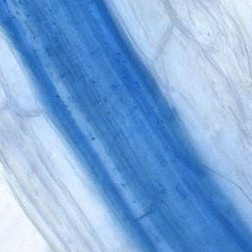

Predicted Label: Unreadable
Confidence: 0.26912943
True Label: M−
Row: 9
Col: 85
Vector: [0.19, 0.21, 0.06, 0.27, 0.16, 0.11]
Std 0.069156826


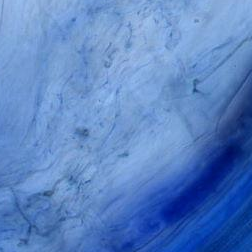

Predicted Label: AM+
Confidence: 0.23527294
True Label: M−
Row: 85
Col: 18
Vector: [0.24, 0.17, 0.03, 0.23, 0.16, 0.17]
Std 0.069482


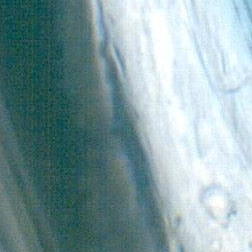

In [11]:
predictions_list.sort(key=lambda x: x.std, reverse=False)
for i in range(5):
    visualise(predictions_list[i])

In [12]:
from sklearn.metrics import confusion_matrix, f1_score
import argparse
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def evaluate_model(x_test, y_test, model, device, batch_size=32):
    model.to(device)
    model.eval()
    num_classes = y_test[0].shape[0]
    # Ensure the model is in evaluation mode
    model.eval()

    # Create a DataLoader for batching
    test_dataset = AmfLoad.CustomNormalisedDataset(x_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    all_y_true = []
    all_y_pred = []

    with torch.no_grad():  # Turn off gradients for evaluation
        for x_batch, y_batch in test_loader:
            # Move the batch to the specified device
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass: Compute predicted outputs by passing input data to the model
            outputs = model(x_batch)

            # Convert y_batch to the expected shape (batch_size,)
            _, y_true_batch = torch.max(y_batch, 1)

            # Accumulate the cross-entropy loss
            loss = criterion(outputs, y_true_batch).item()
            total_loss += loss * x_batch.size(0)

            # Get the predicted class from the model's output
            _, y_pred_batch = torch.max(outputs, 1)

            # Collect predictions
            all_y_true.append(y_true_batch.cpu())
            all_y_pred.append(y_pred_batch.cpu())

    # Concatenate results across all batches
    all_y_true = torch.cat(all_y_true)
    all_y_pred = torch.cat(all_y_pred)

    # Convert tensors to numpy arrays for scikit-learn evaluation
    y_true_np = all_y_true.numpy()
    y_pred_np = all_y_pred.numpy()

    # Calculate F1 score for each class
    class_labels = range(num_classes)
    f1_scores = f1_score(
        y_true_np, y_pred_np, average=None, labels=class_labels, zero_division=0
    )

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_true_np, y_pred_np, labels=range(num_classes))

    # Compute average loss
    average_loss = total_loss / len(test_dataset)

    return average_loss, f1_scores, conf_matrix



l,f1,conf_matrix = evaluate_model(x_test, y_test,model,device)

In [13]:
# ["AMColonised", "Uncolonised", "Background", "Unreadable", "DSE", "Hybrid"]
f1

array([0.63576159, 0.73365731, 0.96487095, 0.31439894, 0.12648221,
       0.109375  ])

In [14]:
conf_matrix

array([[ 672,  207,    0,   25,   26,   29],
       [ 354, 2340,   38,  289,  101,   32],
       [   6,  315, 9421,  310,   11,    1],
       [  71,  318,    5,  238,   12,    4],
       [  24,   34,    0,    4,   16,    3],
       [  28,   11,    0,    0,    6,    7]], dtype=int64)